In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from src.config import QDRANT_URL, QDRANT_API_KEY, OPENAI_API_KEY, OPENAI_MODEL, OPENAI_API_URL,\
     DENSE_EMBEDDING_MODEL_PATH, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, DEVICE
     

from src.search_metrics import (
    run_search_evaluation_pipeline,
    compute_ranking_metrics,
    combine_search_ranking_metrics,
)
from src.plots import plot_combined_search_ranking_metrics

/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = os.path.join(PROCESSED_DATA_DIR, "sakila", "sakila_inline_short.sqlite.db")
DATABASE_NAME = "sakila"


sqlite_config = {
    "params": {
        "url": str(url) 
    },
    "type": "sqlite"}

qdrant_config = {"fastembed_model": DENSE_EMBEDDING_MODEL_PATH,
                 "url": QDRANT_URL, 
                 "api_key": QDRANT_API_KEY,
                 "device": DEVICE}

openai_config = {"api_key": OPENAI_API_KEY,
                 "model": OPENAI_MODEL,
                 "base_url": OPENAI_API_URL}

In [3]:
related_descriptions_csv_path = os.path.join(INTERIM_DATA_DIR, DATABASE_NAME, "query_descriptions", "query_descriptions_inline_short_rewritten_related.csv")

In [4]:
search_result_paths = run_search_evaluation_pipeline(
    related_descriptions_csv_path=related_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    db_config=sqlite_config,
    description_styles=("short", "business", "technical"),
    search_query_columns=None,
    n_results=5,
    comment_style="inline",
    comment_variant="short",
)

print("Search results:", search_result_paths)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2151.70it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2317.25it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2195.66it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Searching (technical): 100%|██████████| 54/54 [00:01<00:00, 35.92it/s]

Search results: [PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/short_top_5.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/business_top_5.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/technical_top_5.csv')]


In [5]:
metrics_paths = compute_ranking_metrics(
    search_result_paths=search_result_paths,
    k=5,
)

print("Metrics:", metrics_paths)

Metrics: [PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_short.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_business.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_technical.csv')]


In [ ]:
for path in metrics_paths:
    print(path.name)
    display(pd.read_csv(path))

,metric,column,k,value
0,mrr,predicted_short,5,0.916667
1,map_at_k,predicted_short,5,0.916667
2,recall_at_k,predicted_short,5,1.000000
3,mrr,predicted_business,5,0.944444
4,map_at_k,predicted_business,5,0.944444
5,recall_at_k,predicted_business,5,1.000000
6,mrr,predicted_technical,5,0.972222
7,map_at_k,predicted_technical,5,0.972222
8,recall_at_k,predicted_technical,5,1.000000
9,mrr,combined,5,0.916667


,metric,column,k,value
0,mrr,predicted_short,5,0.888889
1,map_at_k,predicted_short,5,0.888889
2,recall_at_k,predicted_short,5,1.000000
3,mrr,predicted_business,5,0.916667
4,map_at_k,predicted_business,5,0.916667
5,recall_at_k,predicted_business,5,1.000000
6,mrr,predicted_technical,5,0.944444
7,map_at_k,predicted_technical,5,0.944444
8,recall_at_k,predicted_technical,5,1.000000
9,mrr,combined,5,0.888889


,metric,column,k,value
0,mrr,predicted_short,5,0.851852
1,map_at_k,predicted_short,5,0.851852
2,recall_at_k,predicted_short,5,1.000000
3,mrr,predicted_business,5,0.861111
4,map_at_k,predicted_business,5,0.861111
5,recall_at_k,predicted_business,5,1.000000
6,mrr,predicted_technical,5,0.944444
7,map_at_k,predicted_technical,5,0.944444
8,recall_at_k,predicted_technical,5,1.000000
9,mrr,combined,5,0.851852


Combined metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/combined_search_top_k_combined.xlsx
Combined plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_k_combined.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.916667,0.916667,1
1,business,0.888889,0.888889,1
2,technical,0.851852,0.851852,1


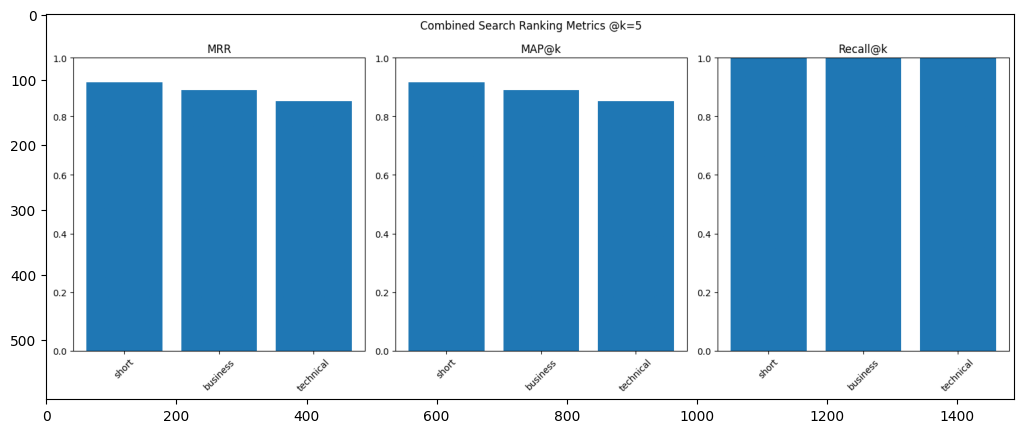

In [4]:
combined_metrics_path = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="combined",
)
combined_plot_path = plot_combined_search_ranking_metrics(
    combined_metrics_path,
    column_mode="combined",
    k=5
)
print("Combined metrics:", combined_metrics_path)
print("Combined plot:", combined_plot_path)
display(pd.read_excel(combined_metrics_path))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(combined_plot_path))

Respective metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/combined_search_top_k_respective.xlsx
Respective plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_k_respective.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.916667,0.916667,1
1,business,0.916667,0.916667,1
2,technical,0.944444,0.944444,1


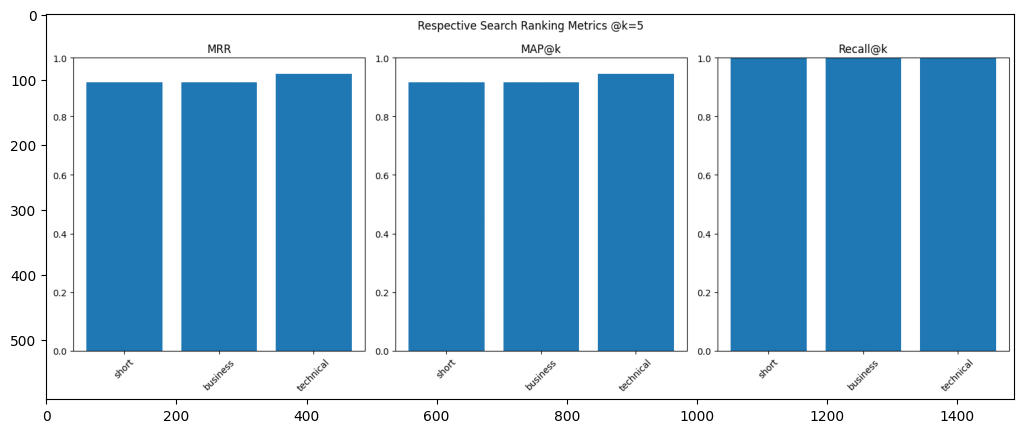

In [6]:
respective_metrics_path = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="respective",
)
respective_plot_path = plot_combined_search_ranking_metrics(
    respective_metrics_path,
    column_mode="respective",
    k=5
)
print("Respective metrics:", respective_metrics_path)
print("Respective plot:", respective_plot_path)
display(pd.read_excel(respective_metrics_path))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(respective_plot_path));